# Travel-time matrix

Load a commune×commune road TTM from `data/processed/tt_matrix` and map travel times from one gmina (random or fixed TERYT). Optionally compare two matrices.

In [120]:
# --- config ---
TTM_A = "ttm_road_popw_poland_roads_2021-12-31_optimal"  # primary stem (.npz preferred, else .csv)
TTM_B = "ttm_road_popw_poland_roads_2012-12-31_optimal"  # comparison; set None to skip diff plot
TTM_A_LABEL = "2021"  # short plot label (None → stem)
TTM_B_LABEL = "2012"
ORIGIN_TERYT = None  # e.g. "1465011"; None → random gmina
RNG_SEED = None  # int for reproducible random origin; ignored if ORIGIN_TERYT set
COMMUNES_GPKG = "communes_2021.gpkg"


In [121]:
from pathlib import Path
import json
import shutil
import subprocess

import ipynbname
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

REPO_ROOT = Path(ipynbname.path()).parent.parent
DATA_ROOT = REPO_ROOT / "data"
TT_DIR = DATA_ROOT / "processed" / "tt_matrix"
COMMUNES_PATH = DATA_ROOT / "processed" / "shapefiles" / COMMUNES_GPKG


def _kpsewhich(name: str) -> str:
    if not shutil.which("kpsewhich"):
        return ""
    return subprocess.run(
        ["kpsewhich", name], capture_output=True, text=True
    ).stdout.strip()


if not _kpsewhich("type1cm.sty"):
    shim_dir = Path.home() / "texmf" / "tex" / "latex" / "type1cm"
    shim_dir.mkdir(parents=True, exist_ok=True)
    (shim_dir / "type1cm.sty").write_text(
        "% Shim for matplotlib usetex: map type1cm -> cm-super type1ec.\n"
        "\\ProvidesPackage{type1cm}\n"
        "\\RequirePackage{type1ec}\n"
    )

_latex_preamble = r"\usepackage[T1]{fontenc}\usepackage{amsmath}\usepackage{amssymb}"
if _kpsewhich("siunitx.sty"):
    _latex_preamble += r"\usepackage{siunitx}[=v2]"

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 16.0,
    "font.family": "serif",
    "font.serif": "Palatino",
    "axes.titlesize": "medium",
    "figure.titlesize": "large",
    "legend.fontsize": "medium",
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.autolayout": True,
    "text.usetex": True,
    "text.latex.preamble": _latex_preamble,
})

_PL_LATEX = {
    "ą": r"\k{a}", "ć": r"\'c", "ę": r"\k{e}", "ł": r"\l{}",
    "ń": r"\'n", "ó": r"\'o", "ś": r"\'s", "ź": r"\'z", "ż": r"\.{z}",
    "Ą": r"\k{A}", "Ć": r"\'C", "Ę": r"\k{E}", "Ł": r"\L{}",
    "Ń": r"\'N", "Ó": r"\'O", "Ś": r"\'S", "Ź": r"\'Z", "Ż": r"\.{Z}",
}


def _fix_utf8_mojibake(s: str) -> str:
    try:
        return s.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s


def latex_text(s: str) -> str:
    s = _fix_utf8_mojibake(str(s))
    for ch, rep in _PL_LATEX.items():
        s = s.replace(ch, rep)
    return s.replace("_", r"\_").replace("&", r"\&").replace("%", r"\%")


def load_ttm(stem: str):
    """Load TTM by stem from TT_DIR (.npz preferred, else .csv). Returns (matrix, ids, label)."""
    stem = Path(stem).stem  # allow accidental .npz/.csv suffix
    npz = TT_DIR / f"{stem}.npz"
    csv = TT_DIR / f"{stem}.csv"
    if npz.exists():
        z = np.load(npz, allow_pickle=True)
        mat = np.asarray(z["matrix"], dtype=np.float32)
        ids = np.asarray(z["ids"]).astype(str)
    elif csv.exists():
        df = pd.read_csv(csv, index_col=0)
        ids = df.index.astype(str).to_numpy()
        mat = df.to_numpy(dtype=np.float32)
    else:
        raise FileNotFoundError(f"No TTM for stem={stem!r} in {TT_DIR}")
    return mat, ids, latex_text(stem)


def row_for(ids: np.ndarray, mat: np.ndarray, teryt: str) -> np.ndarray:
    idx = np.where(ids == str(teryt))[0]
    if idx.size == 0:
        raise KeyError(f"TERYT {teryt} not in TTM ({len(ids)} ids)")
    return mat[int(idx[0])]

In [122]:
communes = gpd.read_file(COMMUNES_PATH, layer="communes")
communes["JPT_KOD_JE"] = communes["JPT_KOD_JE"].astype(str)
communes["JPT_NAZWA_"] = communes["JPT_NAZWA_"].map(_fix_utf8_mojibake)

mat_a, ids_a, label_a = load_ttm(TTM_A)
if TTM_A_LABEL:
    label_a = latex_text(TTM_A_LABEL)

mat_b = ids_b = label_b = None
if TTM_B:
    mat_b, ids_b, label_b = load_ttm(TTM_B)
    if TTM_B_LABEL:
        label_b = latex_text(TTM_B_LABEL)

print(f"{len(communes)} communes  |  TTM_A {mat_a.shape}  |  {TTM_A}")
if mat_b is not None:
    print(f"TTM_B {mat_b.shape}  |  {TTM_B}")


2477 communes  |  TTM_A (2477, 2477)  |  ttm_road_popw_poland_roads_2021-12-31_optimal
TTM_B (2477, 2477)  |  ttm_road_popw_poland_roads_2012-12-31_optimal


In [123]:
rng = np.random.default_rng(RNG_SEED)
in_ttm = communes["JPT_KOD_JE"].isin(ids_a)
pool = communes.loc[in_ttm]

if ORIGIN_TERYT is None:
    gmina = pool.sample(1, random_state=int(rng.integers(0, 2**31 - 1))).iloc[0]
else:
    hit = pool.loc[pool["JPT_KOD_JE"] == str(ORIGIN_TERYT)]
    if hit.empty:
        raise KeyError(f"ORIGIN_TERYT={ORIGIN_TERYT!r} not in communes ∩ TTM_A")
    gmina = hit.iloc[0]

origin = str(gmina["JPT_KOD_JE"])
times_a = row_for(ids_a, mat_a, origin)
plot_df = communes.set_index("JPT_KOD_JE").loc[list(ids_a)].copy()
plot_df["tt_a"] = times_a

if mat_b is not None:
    times_b = row_for(ids_b, mat_b, origin)
    # align B onto A's id order
    pos_b = {t: i for i, t in enumerate(ids_b)}
    aligned_b = np.array(
        [times_b[pos_b[t]] if t in pos_b else np.nan for t in ids_a],
        dtype=np.float32,
    )
    plot_df["tt_b"] = aligned_b
    plot_df["tt_diff"] = plot_df["tt_a"] - plot_df["tt_b"]  # A − B (min)

print(
    f"{gmina['JPT_NAZWA_']}  (TERYT {origin})  "
    f"median $t$={np.nanmedian(times_a):.1f} min  "
    f"max={np.nanmax(times_a):.1f} min"
)


Klucze  (TERYT 1212042)  median $t$=182.4 min  max=391.6 min


## 1. Travel times from origin

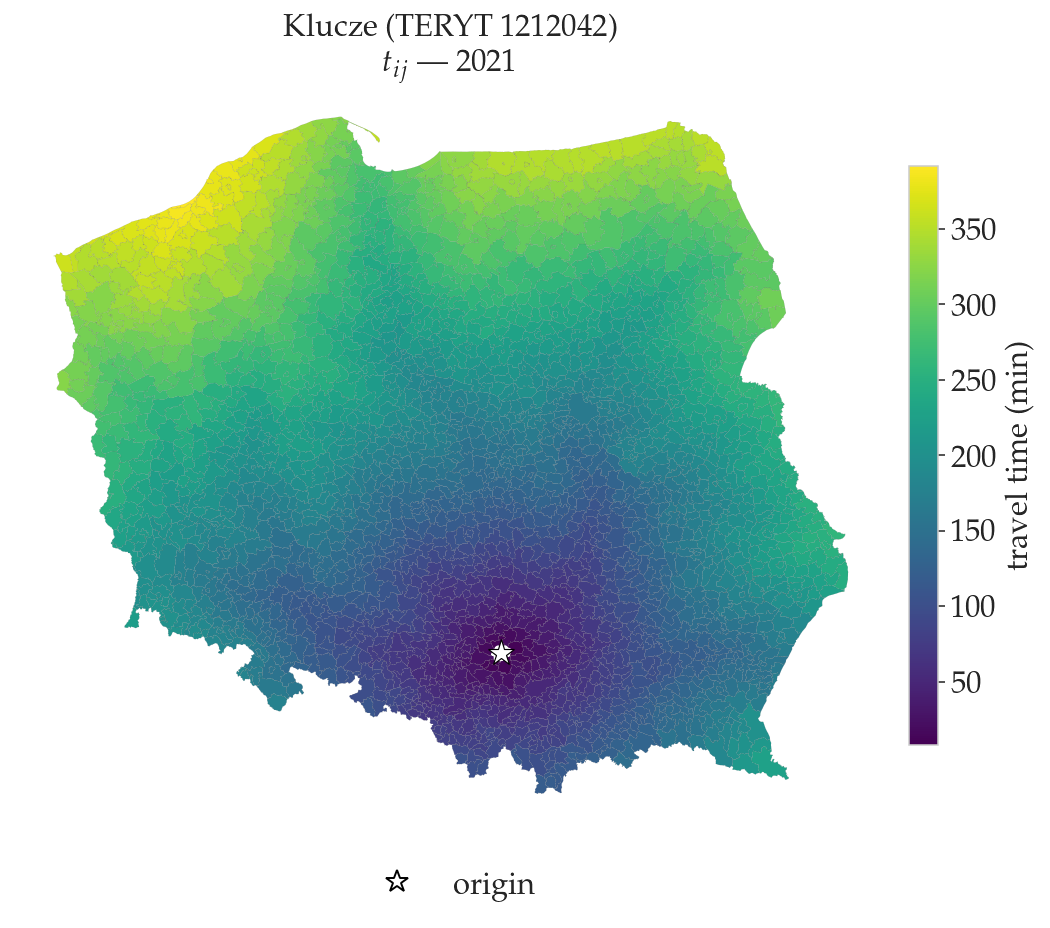

In [124]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.set_dpi(140)

plot_df.plot(
    ax=ax,
    column="tt_a",
    cmap="viridis",
    edgecolor="0.35",
    linewidth=0.05,
    legend=True,
    legend_kwds={
        "label": r"travel time (min)",
        "shrink": 0.55,
        "pad": 0.02,
    },
    missing_kwds={"color": "0.85"},
)
gpd.GeoSeries([gmina.geometry], crs=communes.crs).plot(
    ax=ax,
    facecolor="none",
    edgecolor="1.0",
    linewidth=1.4,
    zorder=3,
)
ax.plot(
    gmina.geometry.centroid.x,
    gmina.geometry.centroid.y,
    marker="*",
    color="1.0",
    markersize=14,
    markeredgecolor="0.0",
    markeredgewidth=0.6,
    zorder=4,
)
ax.legend(
    handles=[
        Line2D(
            [0], [0], marker="*", color="none",
            markerfacecolor="1.0", markeredgecolor="0.0",
            markersize=12, label=r"origin",
        )
    ],
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
)
ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(
    rf"{latex_text(gmina['JPT_NAZWA_'])} (TERYT {origin})"
    + "\n"
    + rf"$t_{{ij}}$ --- {label_a}"
)
plt.show()

## 2. Distribution from origin

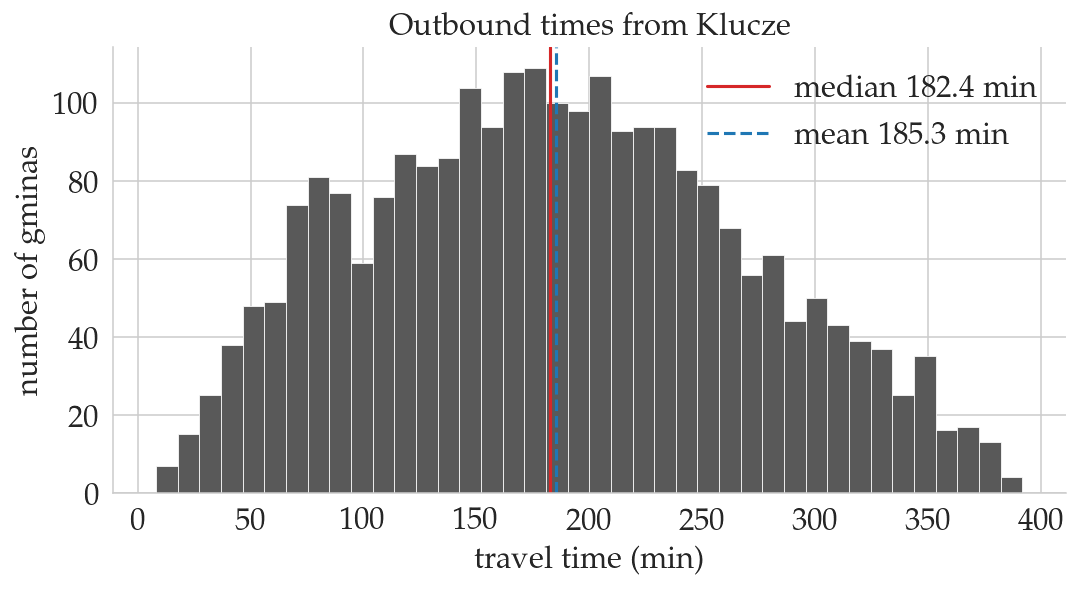

In [125]:
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.set_dpi(140)

vals = times_a[np.isfinite(times_a)]
ax.hist(vals, bins=40, color="0.35", edgecolor="white", linewidth=0.4)
ax.axvline(np.median(vals), color="C3", lw=1.6, label=rf"median ${np.median(vals):.1f}$ min")
ax.axvline(np.mean(vals), color="C0", lw=1.6, ls="--", label=rf"mean ${np.mean(vals):.1f}$ min")
ax.set_xlabel(r"travel time (min)")
ax.set_ylabel(r"number of gminas")
ax.set_title(rf"Outbound times from {latex_text(gmina['JPT_NAZWA_'])}")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()

## 3. Difference $t^{A} - t^{B}$ (skip if `TTM_B` is `None`)

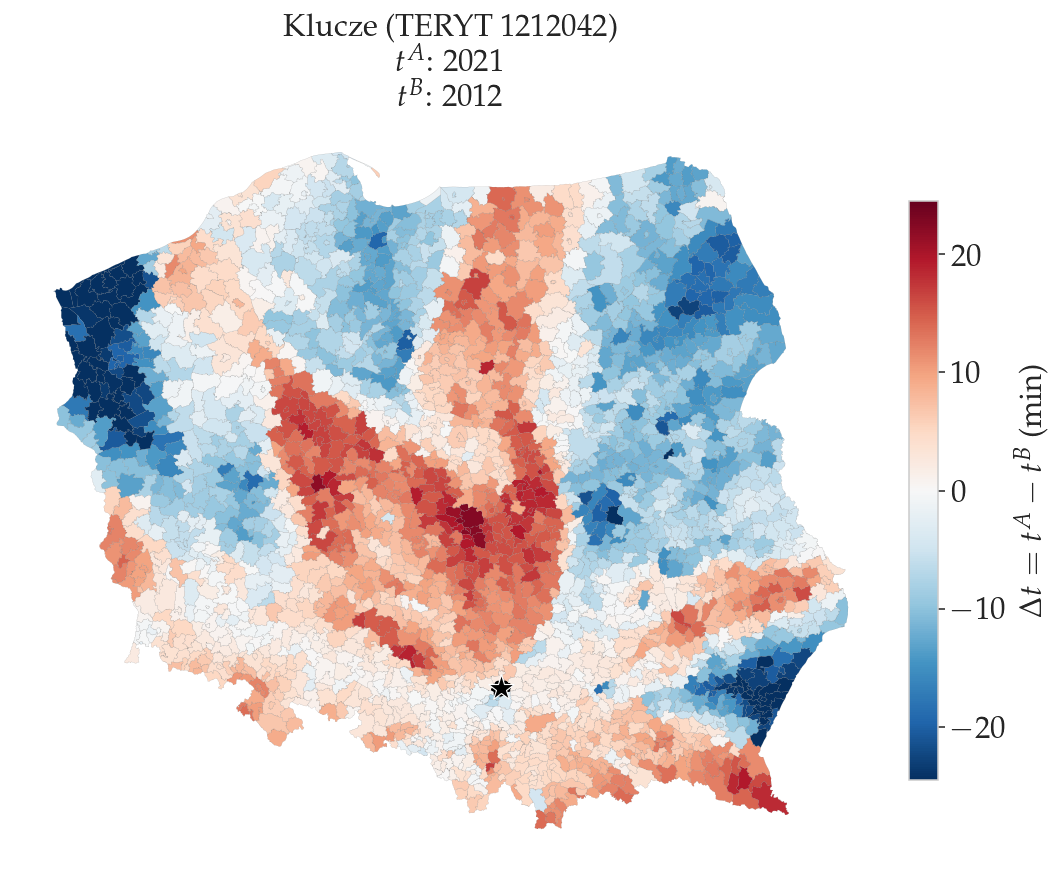

Δt median=+1.13 min  mean=+0.01 min  (negative ⇒ A faster than B)


In [126]:
if mat_b is None:
    print("TTM_B is None — skip comparison plot.")
else:
    diff = plot_df["tt_diff"].to_numpy(dtype=float)
    finite = diff[np.isfinite(diff)]
    lim = float(np.nanpercentile(np.abs(finite), 98)) if finite.size else 1.0
    lim = max(lim, 1e-3)
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    fig, ax = plt.subplots(figsize=(8, 8))
    fig.set_dpi(140)

    plot_df.plot(
        ax=ax,
        column="tt_diff",
        cmap="RdBu_r",
        norm=norm,
        edgecolor="0.35",
        linewidth=0.05,
        legend=True,
        legend_kwds={
            "label": r"$\Delta t = t^{A} - t^{B}$ (min)",
            "shrink": 0.55,
            "pad": 0.02,
        },
        missing_kwds={"color": "0.85"},
    )
    gpd.GeoSeries([gmina.geometry], crs=communes.crs).plot(
        ax=ax,
        facecolor="none",
        edgecolor="0.0",
        linewidth=1.4,
        zorder=3,
    )
    ax.plot(
        gmina.geometry.centroid.x,
        gmina.geometry.centroid.y,
        marker="*",
        color="0.0",
        markersize=14,
        markeredgecolor="1.0",
        markeredgewidth=0.6,
        zorder=4,
    )
    ax.set_axis_off()
    ax.set_aspect("equal")
    ax.set_title(
        rf"{latex_text(gmina['JPT_NAZWA_'])} (TERYT {origin})"
        + "\n"
        + rf"$t^{{A}}$: {label_a}"
        + "\n"
        + rf"$t^{{B}}$: {label_b}"
    )
    plt.show()
    print(
        f"Δt median={np.nanmedian(finite):+.2f} min  "
        f"mean={np.nanmean(finite):+.2f} min  "
        f"(negative ⇒ A faster than B)"
    )